##### Given limited additional inventory, how should inventory be allocated among shortage observations to satisfy as much forecast demand as possible?

In [36]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

data = pd.read_csv(
    '../data/smart_logistics_cleaned.csv',
    parse_dates=['Timestamp']
)

## 1. Optimization Problem

The optimization model determines how a limited replenishment capacity should
be allocated across observations where forecast demand exceeds available
inventory.

The objective is to prioritize inventory for observations with greater
operational risk while reducing remaining inventory shortages.

In [37]:
# Calculate inventory shortage

data['Inventory_Gap'] = (
    data['Inventory_Level'] - data['Demand_Forecast']
)

shortages = data[
    data['Inventory_Gap'] < 0
].copy()

shortages['Shortage_Units'] = (
    -shortages['Inventory_Gap']
)

shortages.shape

(261, 18)

In [38]:
shortages[
    [
        'Asset_ID',
        'Inventory_Level',
        'Demand_Forecast',
        'Shortage_Units',
        'Logistics_Delay'
    ]
].head()

,Asset_ID,Inventory_Level,Demand_Forecast,Shortage_Units,Logistics_Delay
2,Truck_10,190,260,70,0
5,Truck_7,118,189,71,0
7,Truck_9,222,253,31,0
11,Truck_10,234,238,4,0
14,Truck_3,163,231,68,1


In [39]:
# Constraints

# Hypothetical replenishment capacity

REPLENISHMENT_CAPACITY = 500

print(
    f"Available additional inventory: "
    f"{REPLENISHMENT_CAPACITY} units"
)

print(
    f"Total shortage units: "
    f"{shortages['Shortage_Units'].sum()}"
)

Available additional inventory: 500 units
Total shortage units: 16592


In [40]:
shortages['Priority_Score'] = (
    shortages['Shortage_Units'] *
    (1 + shortages['Asset_Utilization'] / 100)
)

In [41]:
from scipy.optimize import linprog

In [42]:
# linprog minimizes, while our business objective is to maximize priority-weighted inventory allocation.
# so we are objective should be negative 

n = len(shortages)

objective = -shortages['Priority_Score'].values

In [43]:
constraint = shortages['Shortage_Units'].values.reshape(1, -1)

In [44]:
result = linprog(
    c=objective,
    A_ub=constraint,
    b_ub=[REPLENISHMENT_CAPACITY],
    bounds=[
        (0, shortage)
        for shortage in shortages['Shortage_Units']
    ],
    method='highs'
)

In [45]:
print("Optimization successful:", result.success)
print("Solver message:", result.message)

Optimization successful: True
Solver message: Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [46]:
# allocations

shortages['Recommended_Allocation'] = result.x

shortages[
    [
        'Asset_ID',
        'Inventory_Level',
        'Demand_Forecast',
        'Shortage_Units',
        'Priority_Score',
        'Recommended_Allocation'
    ]
].sort_values(
    'Recommended_Allocation',
    ascending=False
).head(15)

,Asset_ID,Inventory_Level,Demand_Forecast,Shortage_Units,Priority_Score,Recommended_Allocation
255,Truck_8,133,261,128,255.872,3.90625
2,Truck_10,190,260,70,139.440,0.00000
661,Truck_6,118,239,121,218.526,0.00000
674,Truck_9,135,196,61,103.334,0.00000
668,Truck_1,242,265,23,37.214,0.00000
667,Truck_2,117,277,160,261.920,0.00000
666,Truck_4,282,285,3,5.364,0.00000
663,Truck_3,258,277,19,34.314,0.00000
662,Truck_2,147,173,26,44.460,0.00000
653,Truck_3,176,217,41,71.135,0.00000


In [47]:
# calculate shortages 
shortages['Remaining_Shortage'] = (
    shortages['Shortage_Units'] -
    shortages['Recommended_Allocation']
)

In [48]:
total_shortage_before = shortages['Shortage_Units'].sum()

total_allocated = shortages['Recommended_Allocation'].sum()

total_shortage_after = shortages['Remaining_Shortage'].sum()

print(f"Shortage before optimization: {total_shortage_before:.1f}")
print(f"Inventory allocated: {total_allocated:.1f}")
print(f"Remaining shortage: {total_shortage_after:.1f}")

Shortage before optimization: 16592.0
Inventory allocated: 3.9
Remaining shortage: 16588.1


In [49]:
# load ML trained model

import joblib

best_gb_model = joblib.load(
    '../models/final_gradient_boosting_model.pkl'
)

In [50]:
# Recreate machine learning features

data['Month'] = data['Timestamp'].dt.month
data['Day_of_Week'] = data['Timestamp'].dt.day_name()
data['Hour'] = data['Timestamp'].dt.hour
data['Is_Weekend'] = (data['Timestamp'].dt.dayofweek >= 5).astype(int)

data['Inventory_Gap'] = (
    data['Inventory_Level'] -
    data['Demand_Forecast']
)

data['Inventory_Shortage'] = (
    data['Inventory_Gap'] < 0
).astype(int)

In [51]:
features = [
    'Asset_ID',
    'Inventory_Level',
    'Temperature',
    'Humidity',
    'Traffic_Status',
    'Waiting_Time',
    'User_Transaction_Amount',
    'User_Purchase_Frequency',
    'Asset_Utilization',
    'Demand_Forecast',
    'Inventory_Gap',
    'Inventory_Shortage',
    'Month',
    'Day_of_Week',
    'Hour',
    'Is_Weekend'
]

In [52]:
# create shortage subset

shortages = data[
    data['Inventory_Gap'] < 0
].copy()

shortages['Shortage_Units'] = (
    -shortages['Inventory_Gap']
)

In [53]:
shortages.shape

(261, 23)

### Generate predicted delay risk

In [54]:
shortages['Predicted_Delay_Risk'] = (
    best_gb_model.predict_proba(
        shortages[features]
    )[:, 1]
)

In [55]:
shortages[
    [
        'Asset_ID',
        'Traffic_Status',
        'Inventory_Level',
        'Demand_Forecast',
        'Shortage_Units',
        'Predicted_Delay_Risk'
    ]
].sort_values(
    'Predicted_Delay_Risk',
    ascending=False
).head(10)

,Asset_ID,Traffic_Status,Inventory_Level,Demand_Forecast,Shortage_Units,Predicted_Delay_Risk
545,Truck_4,Heavy,106,276,170,0.987088
223,Truck_3,Heavy,132,140,8,0.982018
763,Truck_9,Heavy,200,299,99,0.980674
631,Truck_8,Heavy,131,149,18,0.980011
69,Truck_9,Heavy,203,254,51,0.979739
492,Truck_10,Heavy,180,203,23,0.979123
535,Truck_8,Heavy,184,299,115,0.978774
92,Truck_1,Heavy,106,125,19,0.978071
539,Truck_6,Heavy,202,213,11,0.977778
264,Truck_10,Heavy,164,268,104,0.977570


In [56]:
# Priority 

shortages['Priority_Score'] = (
    shortages['Shortage_Units'] *
    shortages['Predicted_Delay_Risk']
)

## 2. Inventory Allocation Optimization

A limited replenishment capacity of 500 units is assumed for this scenario.
The optimization allocates these units across shortage observations.

Each observation can receive between zero units and its full shortage amount.
The objective prioritizes observations with larger shortages and higher
predicted logistics-delay risk.

In [57]:
from scipy.optimize import linprog

REPLENISHMENT_CAPACITY = 500

objective = -shortages['Predicted_Delay_Risk'].values

bounds = [
    (0, shortage)
    for shortage in shortages['Shortage_Units']
]

# Each decision variable represents one inventory unit allocated
A_ub = np.ones((1, len(shortages)))
b_ub = [REPLENISHMENT_CAPACITY]

result = linprog(
    c=objective,
    A_ub=A_ub,
    b_ub=b_ub,
    bounds=bounds,
    method='highs'
)

shortages['Recommended_Allocation'] = result.x

shortages['Remaining_Shortage'] = (
    shortages['Shortage_Units']
    - shortages['Recommended_Allocation']
)

print("Optimization successful:", result.success)
print(f"Inventory available: {REPLENISHMENT_CAPACITY} units")
print(f"Inventory allocated: {shortages['Recommended_Allocation'].sum():.0f} units")
print(f"Shortage before: {shortages['Shortage_Units'].sum():.0f} units")
print(f"Shortage after: {shortages['Remaining_Shortage'].sum():.0f} units")

Optimization successful: True
Inventory available: 500 units
Inventory allocated: 500 units
Shortage before: 16592 units
Shortage after: 16092 units


In [58]:
print("Optimization successful:", result.success)
print(result.message)

Optimization successful: True
Optimization terminated successfully. (HiGHS Status 7: Optimal)


In [59]:
# add recommended allocation

shortages['Recommended_Allocation'] = result.x

In [60]:
shortages['Remaining_Shortage'] = (
    shortages['Shortage_Units']
    - shortages['Recommended_Allocation']
)

In [61]:
allocation_results = (
    shortages[
        [
            'Asset_ID',
            'Traffic_Status',
            'Inventory_Level',
            'Demand_Forecast',
            'Shortage_Units',
            'Predicted_Delay_Risk',
            'Priority_Score',
            'Recommended_Allocation',
            'Remaining_Shortage'
        ]
    ]
    .sort_values(
        'Recommended_Allocation',
        ascending=False
    )
)

allocation_results.head(15)

,Asset_ID,Traffic_Status,Inventory_Level,Demand_Forecast,Shortage_Units,Predicted_Delay_Risk,Priority_Score,Recommended_Allocation,Remaining_Shortage
545,Truck_4,Heavy,106,276,170,0.987088,167.804954,170.0,0.0
535,Truck_8,Heavy,184,299,115,0.978774,112.558955,115.0,0.0
763,Truck_9,Heavy,200,299,99,0.980674,97.086720,99.0,0.0
69,Truck_9,Heavy,203,254,51,0.979739,49.966664,51.0,0.0
492,Truck_10,Heavy,180,203,23,0.979123,22.519839,23.0,0.0
631,Truck_8,Heavy,131,149,18,0.980011,17.640199,18.0,0.0
92,Truck_1,Heavy,106,125,19,0.978071,18.583349,16.0,3.0
223,Truck_3,Heavy,132,140,8,0.982018,7.856142,8.0,0.0
689,Truck_9,Clear,201,242,41,0.421467,17.280130,0.0,41.0
651,Truck_5,Clear,194,293,99,0.370550,36.684436,0.0,99.0


In [62]:
total_shortage_before = shortages['Shortage_Units'].sum()

total_allocated = shortages['Recommended_Allocation'].sum()

total_shortage_after = shortages['Remaining_Shortage'].sum()

shortage_reduction = (
    total_shortage_before - total_shortage_after
)

print(f"Total shortage before: {total_shortage_before:.1f} units")
print(f"Inventory allocated: {total_allocated:.1f} units")
print(f"Total shortage after: {total_shortage_after:.1f} units")
print(f"Shortage reduction: {shortage_reduction:.1f} units")

Total shortage before: 16592.0 units
Inventory allocated: 500.0 units
Total shortage after: 16092.0 units
Shortage reduction: 500.0 units


In [63]:
# Because the ML model strongly associates Heavy traffic with delay,
# many of the high-priority observations to be Heavy traffic.

# sanity check

high_priority = shortages.nlargest(
    20,
    'Priority_Score'
)

high_priority[
    [
        'Asset_ID',
        'Traffic_Status',
        'Shortage_Units',
        'Predicted_Delay_Risk',
        'Priority_Score'
    ]
]

,Asset_ID,Traffic_Status,Shortage_Units,Predicted_Delay_Risk,Priority_Score
545,Truck_4,Heavy,170,0.987088,167.804954
667,Truck_2,Heavy,160,0.974034,155.845399
199,Truck_7,Heavy,150,0.974821,146.223113
738,Truck_10,Heavy,145,0.975303,141.418947
649,Truck_3,Heavy,133,0.964849,128.324869
623,Truck_3,Heavy,126,0.964045,121.469733
788,Truck_1,Heavy,119,0.967051,115.079107
61,Truck_4,Heavy,116,0.976739,113.301682
603,Truck_4,Heavy,116,0.975108,113.112555
535,Truck_8,Heavy,115,0.978774,112.558955


In [64]:
high_priority['Traffic_Status'].value_counts()

Traffic_Status
Heavy     17
Clear      2
Detour     1
Name: count, dtype: int64

In [65]:
print("Optimization successful:", result.success)

print(
    f"Total shortage before: "
    f"{shortages['Shortage_Units'].sum():.0f} units"
)

print(
    f"Total inventory allocated: "
    f"{shortages['Recommended_Allocation'].sum():.0f} units"
)

print(
    f"Remaining shortage: "
    f"{shortages['Remaining_Shortage'].sum():.0f} units"
)

Optimization successful: True
Total shortage before: 16592 units
Total inventory allocated: 500 units
Remaining shortage: 16092 units


In [66]:
allocated = shortages[
    shortages['Recommended_Allocation'] > 0.01
][
    [
        'Asset_ID',
        'Traffic_Status',
        'Inventory_Level',
        'Demand_Forecast',
        'Shortage_Units',
        'Predicted_Delay_Risk',
        'Recommended_Allocation',
        'Remaining_Shortage'
    ]
].sort_values(
    'Recommended_Allocation',
    ascending=False
)

allocated

,Asset_ID,Traffic_Status,Inventory_Level,Demand_Forecast,Shortage_Units,Predicted_Delay_Risk,Recommended_Allocation,Remaining_Shortage
545,Truck_4,Heavy,106,276,170,0.987088,170.0,0.0
535,Truck_8,Heavy,184,299,115,0.978774,115.0,0.0
763,Truck_9,Heavy,200,299,99,0.980674,99.0,0.0
69,Truck_9,Heavy,203,254,51,0.979739,51.0,0.0
492,Truck_10,Heavy,180,203,23,0.979123,23.0,0.0
631,Truck_8,Heavy,131,149,18,0.980011,18.0,0.0
92,Truck_1,Heavy,106,125,19,0.978071,16.0,3.0
223,Truck_3,Heavy,132,140,8,0.982018,8.0,0.0


In [67]:
# by truck

allocation_by_truck = (
    allocated.groupby('Asset_ID')['Recommended_Allocation']
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

allocation_by_truck

Asset_ID
Truck_4     170.0
Truck_9     150.0
Truck_8     133.0
Truck_10     23.0
Truck_1      16.0
Truck_3       8.0
Name: Recommended_Allocation, dtype: float64

In [68]:
# by traffic condition
allocation_by_traffic = (
    allocated.groupby('Traffic_Status')['Recommended_Allocation']
    .sum()
    .sort_values(ascending=False)
    .round(1)
)

allocation_by_traffic

Traffic_Status
Heavy    500.0
Name: Recommended_Allocation, dtype: float64

Optimization Result: 

Under the hypothetical 500-unit replenishment constraint, the optimization model allocated all available inventory to shortage observations associated with Heavy traffic. This occurred because the machine-learning model assigned these observations the highest predicted delay risks. The allocation reduced the total inventory shortage from 16,592 to 16,092 units. Most selected shortages were fully replenished, with the final selected observation partially replenished when the 500-unit capacity was exhausted.

This analysis demonstrates how predictive model outputs can be incorporated into a prescriptive resource-allocation framework. However, the optimization does not establish that additional inventory would cause a reduction in logistics delays; predicted delay risk is used only as a prioritization signal in this hypothetical scenario.

In [69]:
# scenario analysis

capacities = [250, 500, 1000, 2000]

scenario_results = []

for capacity in capacities:

    result_scenario = linprog(
        c=-shortages['Predicted_Delay_Risk'].values,
        A_ub=np.ones((1, len(shortages))),
        b_ub=[capacity],
        bounds=[
            (0, shortage)
            for shortage in shortages['Shortage_Units']
        ],
        method='highs'
    )

    allocated_units = result_scenario.x.sum()

    remaining_shortage = (
        shortages['Shortage_Units'].sum()
        - allocated_units
    )

    scenario_results.append({
        'Replenishment_Capacity': capacity,
        'Inventory_Allocated': allocated_units,
        'Remaining_Shortage': remaining_shortage,
        'Shortage_Reduction_Percent':
            allocated_units /
            shortages['Shortage_Units'].sum() * 100
    })

scenario_results = pd.DataFrame(scenario_results)

scenario_results.round(1)

,Replenishment_Capacity,Inventory_Allocated,Remaining_Shortage,Shortage_Reduction_Percent
0,250,250.0,16342.0,1.5
1,500,500.0,16092.0,3.0
2,1000,1000.0,15592.0,6.0
3,2000,2000.0,14592.0,12.1


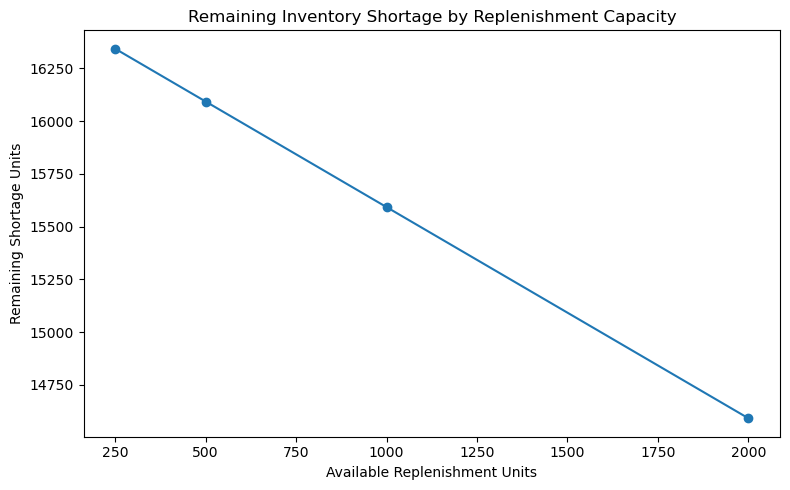

In [70]:
plt.figure(figsize=(8, 5))

plt.plot(
    scenario_results['Replenishment_Capacity'],
    scenario_results['Remaining_Shortage'],
    marker='o'
)

plt.title('Remaining Inventory Shortage by Replenishment Capacity')
plt.xlabel('Available Replenishment Units')
plt.ylabel('Remaining Shortage Units')

plt.tight_layout()


plt.savefig(
    '../images/optimization_scenarios.png',
    dpi=300,
    bbox_inches='tight'
)

plt.show()